# A-001 Beginner Data Exploration + Machine Learning Lab
## From raw sensor data → exploration → Normal / Abnormal classification

This notebook is designed for **complete beginners**.

We will use one enterprise scenario throughout:

> **Asset A-001 — a synthetic cooling-water pump**

The goal is not to build the most advanced model.  
The goal is to understand the **complete data + machine-learning workflow**.

### What you will practice

1. Connect to the SQLite database
2. Load A-001 sensor data
3. Understand rows, columns and data types
4. Check missing values and class balance
5. Perform **univariate analysis**
6. Perform **bivariate analysis**
7. Perform a small **multivariate exploration**
8. Choose feature `X` and target `y`
9. Split data into train/test
10. Train a simple Decision Tree classifier
11. Evaluate the model
12. Use the model on new A-001 readings
13. Try your own experiments

### Important boundary

This notebook **does not predict pump failure**.

It predicts the existing synthetic label:

- `0` = Normal
- `1` = Abnormal

An abnormal prediction means:

> “This reading looks like historical readings labelled abnormal.”

It does **not** mean the pump has failed or that an operational action should be taken automatically.

# PART 1 — Setup

We start with only a few libraries:

- `sqlite3` → read the SQLite database
- `pandas` → work with tables
- `matplotlib` → charts
- `scikit-learn` → machine learning

In [0]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Database location

This uses the same final Databricks Volume location as the rest of the ENEC training:

`/Volumes/workspace/nuclear_enterprise_360/training_files/nuclear_enterprise_360_v2_2_clean.db`

In [0]:
DB_PATH = "/Volumes/v5_nuclear_enterprise_360/v5_nuclear_enterprise_360/training_files/nuclear_enterprise_360_v2_2_clean.db"

print("Database path:")
print(DB_PATH)

Database path:
/Volumes/v5_nuclear_enterprise_360/v5_nuclear_enterprise_360/training_files/nuclear_enterprise_360_v2_2_clean.db


# PART 2 — Load A-001 data

For exploration we load several sensor columns.

**Important:** loading many columns for exploration does **not** mean we must use all of them in the model.

In [0]:
conn = sqlite3.connect(DB_PATH)

query = '''
SELECT
    reading_timestamp,
    asset_id,
    temperature_c,
    vibration_mm_s,
    pressure_bar,
    flow_rate_m3_h,
    electrical_current_a,
    ambient_temperature_c,
    sensor_quality,
    anomaly_flag
FROM sensor_readings
WHERE asset_id = 'A-001'
ORDER BY reading_timestamp
'''

df = pd.read_sql_query(query, conn)
conn.close()

df["reading_timestamp"] = pd.to_datetime(df["reading_timestamp"])

print("Rows loaded:", len(df))
print("Columns loaded:", len(df.columns))
display(df.head(10))

Rows loaded: 1820
Columns loaded: 10


reading_timestamp,asset_id,temperature_c,vibration_mm_s,pressure_bar,flow_rate_m3_h,electrical_current_a,ambient_temperature_c,sensor_quality,anomaly_flag
2025-05-28T00:00:00.000Z,A-001,51.85,0.95,8.81,95.2,37.56,28.5,GOOD,0
2025-05-28T06:00:00.000Z,A-001,52.44,0.982,8.61,92.76,38.49,29.1,GOOD,0
2025-05-28T12:00:00.000Z,A-001,51.94,0.977,8.4,95.89,37.71,28.6,GOOD,0
2025-05-28T18:00:00.000Z,A-001,51.44,0.971,8.65,99.0,36.92,28.09,GOOD,0
2025-05-29T00:00:00.000Z,A-001,52.02,0.999,8.9,96.45,37.83,28.68,GOOD,0
2025-05-29T06:00:00.000Z,A-001,52.59,1.025,8.69,93.84,38.73,29.26,GOOD,0
2025-05-29T12:00:00.000Z,A-001,52.06,1.013,8.47,96.76,37.9,28.73,GOOD,0
2025-05-29T18:00:00.000Z,A-001,51.53,0.998,8.7,99.6,37.05,28.2,GOOD,0
2025-05-30T00:00:00.000Z,A-001,52.07,1.016,8.93,96.76,37.9,28.75,GOOD,0
2025-05-30T06:00:00.000Z,A-001,52.59,1.031,8.69,93.84,38.73,29.29,GOOD,0


## First beginner question: what is a row and what is a column?

- **One row** = one A-001 sensor reading at one timestamp
- **One column** = one piece of information about that reading

Examples:

- `vibration_mm_s`
- `temperature_c`
- `pressure_bar`
- `anomaly_flag`

In [0]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- reading_timestamp
- asset_id
- temperature_c
- vibration_mm_s
- pressure_bar
- flow_rate_m3_h
- electrical_current_a
- ambient_temperature_c
- sensor_quality
- anomaly_flag


# PART 3 — Basic data understanding

Before making charts or models, always inspect the dataset.

We want to know:

- How many rows?
- What data types?
- Are values missing?
- What is the numerical range?
- How many Normal vs Abnormal labels?

In [0]:
print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)

Shape (rows, columns): (1820, 10)

Data types:
reading_timestamp        datetime64[ns]
asset_id                         object
temperature_c                   float64
vibration_mm_s                  float64
pressure_bar                    float64
flow_rate_m3_h                  float64
electrical_current_a            float64
ambient_temperature_c           float64
sensor_quality                   object
anomaly_flag                      int64
dtype: object


In [0]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_values"))

Missing values per column:


missing_values
0
0
0
0
0
0
0
0
0
0


In [0]:
numeric_columns = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "flow_rate_m3_h",
    "electrical_current_a",
    "ambient_temperature_c",
]

print("Numerical summary:")
display(df[numeric_columns].describe().T)

Numerical summary:


count,mean,std,min,25%,50%,75%,max
1820.0,52.88869230769231,1.60403807500478,51.16,52.11,52.46,52.93,61.78
1820.0,1.361192857142857,0.7493779341822262,0.881,1.064,1.178,1.29025,5.754
1820.0,8.588884615384616,0.24269971828189774,7.9,8.46,8.61,8.72,9.3
1820.0,94.79713186813187,2.6167824781306095,88.01,93.32,94.86,96.49,99.99
1820.0,37.90993406593407,1.3160498210323208,35.03,37.2,37.73,38.32,45.63
1820.0,29.416972527472527,2.4082540876653082,26.27,27.71,28.965,29.99,37.46


## Target balance: Normal vs Abnormal

This is very important.

If one class is much more common than another, we call it **class imbalance**.

In [0]:
class_counts = df["anomaly_flag"].value_counts().sort_index()

print("0 = Normal")
print("1 = Abnormal")
print()
print(class_counts)

normal_count = int(class_counts.get(0, 0))
abnormal_count = int(class_counts.get(1, 0))
abnormal_pct = abnormal_count / len(df) * 100

print()
print(f"Normal readings:   {normal_count:,}")
print(f"Abnormal readings: {abnormal_count:,}")
print(f"Abnormal %:        {abnormal_pct:.2f}%")

0 = Normal
1 = Abnormal

anomaly_flag
0    1797
1      23
Name: count, dtype: int64

Normal readings:   1,797
Abnormal readings: 23
Abnormal %:        1.26%


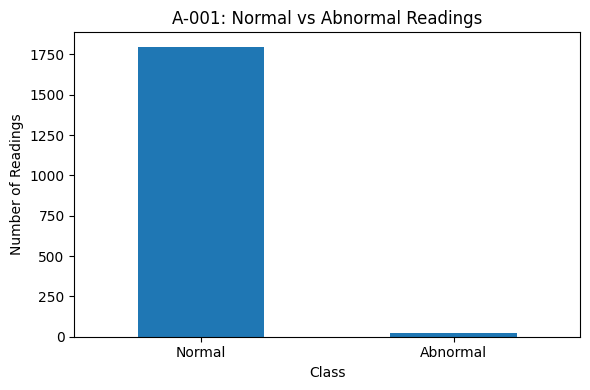

In [0]:
plt.figure(figsize=(6, 4))
class_counts.rename(index={0: "Normal", 1: "Abnormal"}).plot(kind="bar")
plt.title("A-001: Normal vs Abnormal Readings")
plt.xlabel("Class")
plt.ylabel("Number of Readings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# PART 4 — Univariate Analysis

## What is univariate analysis?

**Uni = one**

We study **one variable at a time**.

Typical questions:

- What is the average?
- What is the minimum and maximum?
- Is the distribution skewed?
- Are there unusual values?
- How does the variable change over time?

## 4.1 Vibration — summary statistics

In [0]:
vibration = df["vibration_mm_s"]

print("A-001 vibration summary")
print("-----------------------")
print(f"Count:  {vibration.count():,}")
print(f"Mean:   {vibration.mean():.3f} mm/s")
print(f"Median: {vibration.median():.3f} mm/s")
print(f"Min:    {vibration.min():.3f} mm/s")
print(f"Max:    {vibration.max():.3f} mm/s")
print(f"Std:    {vibration.std():.3f} mm/s")

A-001 vibration summary
-----------------------
Count:  1,820
Mean:   1.361 mm/s
Median: 1.178 mm/s
Min:    0.881 mm/s
Max:    5.754 mm/s
Std:    0.749 mm/s


## 4.2 Vibration distribution — histogram

A histogram answers:

> “Which vibration values occur most often?”

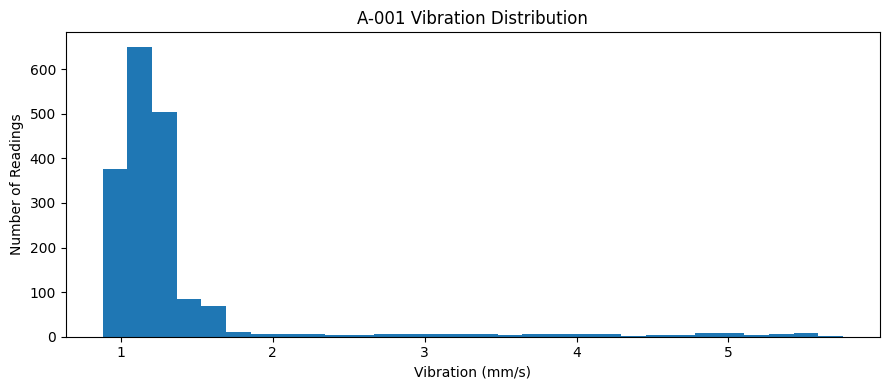

In [0]:
plt.figure(figsize=(9, 4))
plt.hist(df["vibration_mm_s"], bins=30)
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Number of Readings")
plt.title("A-001 Vibration Distribution")
plt.tight_layout()
plt.show()

## 4.3 Vibration over time

A histogram tells us **what values exist**.

A time plot tells us **when they happened**.

In [0]:
plt.figure(figsize=(12, 4))
plt.plot(df["reading_timestamp"], df["vibration_mm_s"])
plt.xlabel("Time")
plt.ylabel("Vibration (mm/s)")
plt.title("A-001 Vibration Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.4 Temperature distribution

Try the same univariate thinking with another sensor.

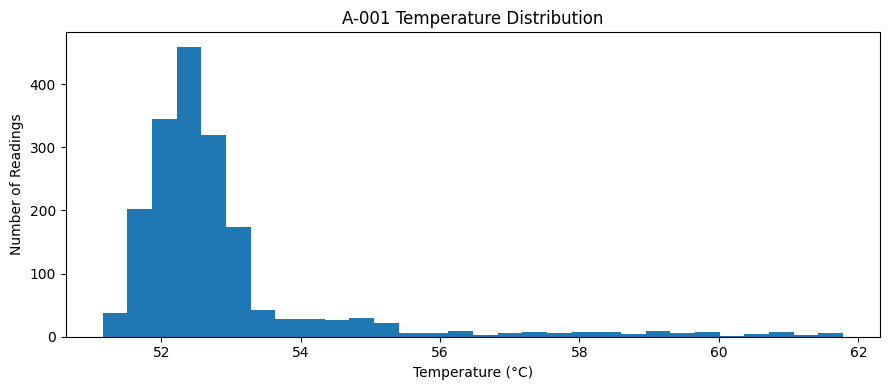

In [0]:
plt.figure(figsize=(9, 4))
plt.hist(df["temperature_c"], bins=30)
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Readings")
plt.title("A-001 Temperature Distribution")
plt.tight_layout()
plt.show()

## 4.5 Electrical current distribution

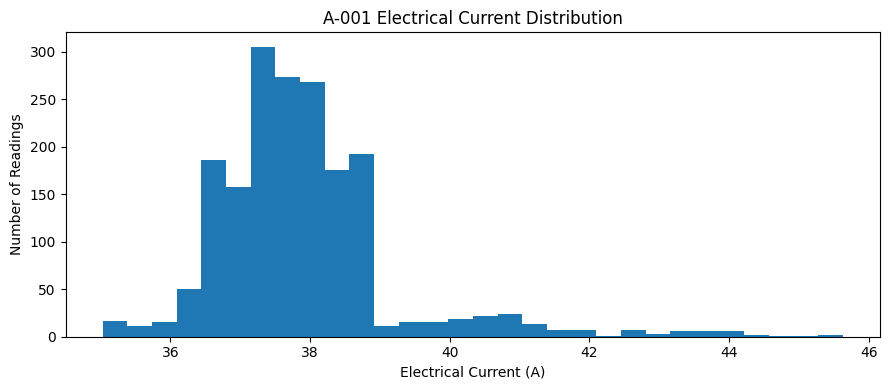

In [0]:
plt.figure(figsize=(9, 4))
plt.hist(df["electrical_current_a"], bins=30)
plt.xlabel("Electrical Current (A)")
plt.ylabel("Number of Readings")
plt.title("A-001 Electrical Current Distribution")
plt.tight_layout()
plt.show()

## 4.6 Sensor quality

Not every useful variable has to be continuous.

`sensor_quality` is categorical.

Sensor quality counts:


count
1789
18
13


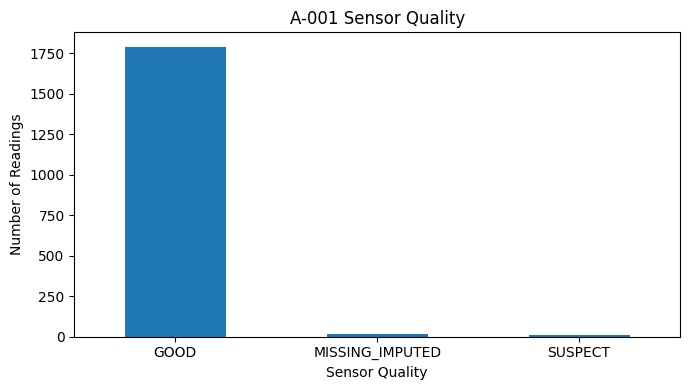

In [0]:
print("Sensor quality counts:")
display(df["sensor_quality"].value_counts(dropna=False).to_frame("count"))

plt.figure(figsize=(7, 4))
df["sensor_quality"].value_counts(dropna=False).plot(kind="bar")
plt.xlabel("Sensor Quality")
plt.ylabel("Number of Readings")
plt.title("A-001 Sensor Quality")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# PART 5 — Bivariate Analysis

## What is bivariate analysis?

**Bi = two**

We study **two variables together**.

Examples:

- Vibration vs anomaly
- Vibration vs temperature
- Vibration vs electrical current
- Sensor quality vs anomaly

This helps us see whether variables appear related.

## 5.1 Vibration vs Anomaly

This is the most important bivariate analysis for our simple model.

We want to ask:

> “Are vibration values different for Normal and Abnormal readings?”

In [0]:
normal_vibration = df.loc[df["anomaly_flag"] == 0, "vibration_mm_s"]
abnormal_vibration = df.loc[df["anomaly_flag"] == 1, "vibration_mm_s"]

print("Normal vibration:")
print(f"  Mean: {normal_vibration.mean():.3f}")
print(f"  Max:  {normal_vibration.max():.3f}")
print()

print("Abnormal vibration:")
print(f"  Mean: {abnormal_vibration.mean():.3f}")
print(f"  Min:  {abnormal_vibration.min():.3f}")

In [0]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [normal_vibration, abnormal_vibration],
    tick_labels=["Normal", "Abnormal"]
)
plt.ylabel("Vibration (mm/s)")
plt.title("A-001 Vibration: Normal vs Abnormal")
plt.tight_layout()
plt.show()

### What should you notice?

If the two groups are clearly separated, vibration may be a useful feature for classification.

Do **not** assume this will always happen in real-world data.  
Real sensor data is usually noisier and classes often overlap.

## 5.2 Vibration vs Temperature

Each point below represents one sensor reading.

In [0]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["vibration_mm_s"],
    df["temperature_c"],
    alpha=0.6
)
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Temperature (°C)")
plt.title("A-001: Vibration vs Temperature")
plt.tight_layout()
plt.show()

corr_vib_temp = df["vibration_mm_s"].corr(df["temperature_c"])
print(f"Correlation between vibration and temperature: {corr_vib_temp:.3f}")

## 5.3 Vibration vs Electrical Current

In [0]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["vibration_mm_s"],
    df["electrical_current_a"],
    alpha=0.6
)
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Electrical Current (A)")
plt.title("A-001: Vibration vs Electrical Current")
plt.tight_layout()
plt.show()

corr_vib_current = df["vibration_mm_s"].corr(df["electrical_current_a"])
print(f"Correlation between vibration and current: {corr_vib_current:.3f}")

## 5.4 Compare average sensors by Normal / Abnormal class

This is another easy bivariate technique:

> Group by the target, then compare averages.

In [0]:
group_summary = (
    df.groupby("anomaly_flag")[numeric_columns]
      .mean()
      .rename(index={0: "Normal", 1: "Abnormal"})
)

display(group_summary.round(3))

## 5.5 Sensor Quality vs Anomaly

This compares **two categorical variables**.

In [0]:
quality_vs_anomaly = pd.crosstab(
    df["sensor_quality"],
    df["anomaly_flag"],
    margins=True
)

quality_vs_anomaly = quality_vs_anomaly.rename(columns={0: "Normal", 1: "Abnormal"})

display(quality_vs_anomaly)

# PART 6 — Small Multivariate Exploration

## What is multivariate analysis?

We look at **several variables together**.

For beginners, a correlation matrix is a simple starting point.

### Important

Correlation tells us whether numerical variables move together.

It does **not** prove that one variable causes another.

In [0]:
correlation_columns = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "flow_rate_m3_h",
    "electrical_current_a",
    "ambient_temperature_c",
    "anomaly_flag",
]

corr = df[correlation_columns].corr()

display(corr.round(3))

temperature_c,vibration_mm_s,pressure_bar,flow_rate_m3_h,electrical_current_a,ambient_temperature_c,anomaly_flag
1.0,0.93,0.069,-0.254,0.73,0.427,0.543
0.93,1.0,0.06,-0.122,0.684,0.255,0.608
0.069,0.06,1.0,0.089,0.071,0.067,0.071
-0.254,-0.122,0.089,1.0,-0.324,-0.173,-0.085
0.73,0.684,0.071,-0.324,1.0,0.236,0.401
0.427,0.255,0.067,-0.173,0.236,1.0,-0.023
0.543,0.608,0.071,-0.085,0.401,-0.023,1.0


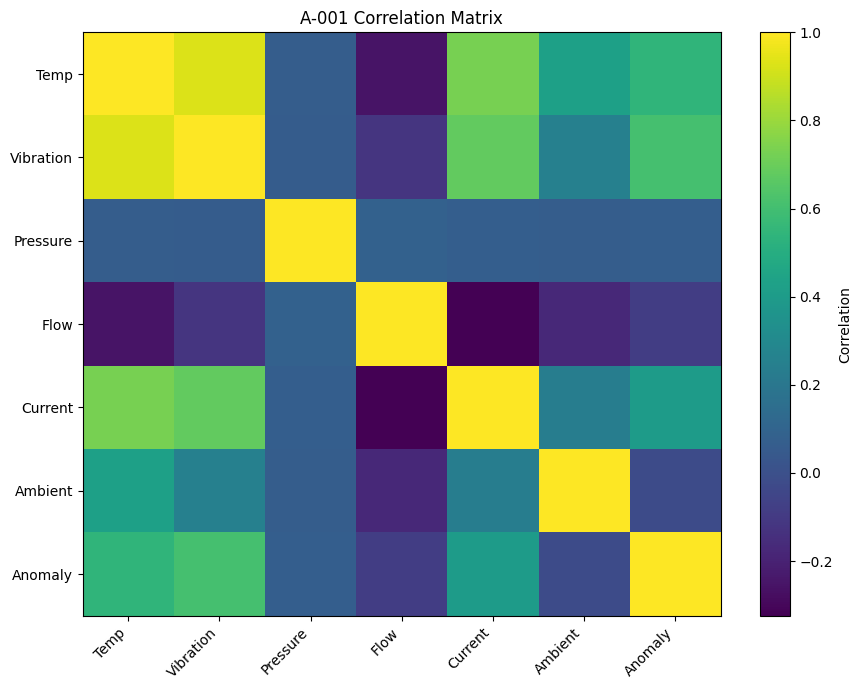

In [0]:
plt.figure(figsize=(9, 7))

plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")

labels = [
    "Temp",
    "Vibration",
    "Pressure",
    "Flow",
    "Current",
    "Ambient",
    "Anomaly"
]

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.title("A-001 Correlation Matrix")
plt.tight_layout()
plt.show()

## Exploration checkpoint

Before ML, discuss:

1. Which variable seems most clearly related to `anomaly_flag`?
2. Which variables seem strongly related to each other?
3. Are any variables surprisingly weak?
4. Would adding more variables automatically make the model better?
5. Could highly related variables contain duplicate information?

For our **first ML model**, we will still use only:

> `vibration_mm_s → anomaly_flag`

The exploration can be broad even when the model stays simple.

# PART 7 — Prepare the Machine Learning Problem

In machine learning:

- **X = features / inputs**
- **y = target / answer**

For the beginner model:

- `X = vibration_mm_s`
- `y = anomaly_flag`

In [0]:
X = df[["vibration_mm_s"]]
y = df["anomaly_flag"]

print("Feature X:")
display(X.head())

print("Target y:")
display(y.head())

print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature X:


vibration_mm_s
0.95
0.982
0.977
0.971
0.999


Target y:


0    0
1    0
2    0
3    0
4    0
Name: anomaly_flag, dtype: int64


X shape: (1820, 1)
y shape: (1820,)


# PART 8 — Train / Test Split

We do not want to test the model using the same examples it studied.

We use:

- **75% training data**
- **25% testing data**

`stratify=y` helps preserve the rare Normal/Abnormal balance in both sets.

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print()

print("Training class counts:")
print(y_train.value_counts().sort_index())
print()

print("Testing class counts:")
print(y_test.value_counts().sort_index())

Training rows: 1365
Testing rows: 455

Training class counts:
anomaly_flag
0    1348
1      17
Name: count, dtype: int64

Testing class counts:
anomaly_flag
0    449
1      6
Name: count, dtype: int64


In [0]:
train_response_rate = y_train.mean()
test_response_rate = y_test.mean()

print(f"Training response rate: {train_response_rate * 100:.2f}%")
print(f"Testing response rate:  {test_response_rate * 100:.2f}%")

Training response rate: 1.25%
Testing response rate:  1.32%


# PART 9 — Train a Simple Decision Tree

We deliberately use:

`max_depth=1`

That means the tree can make only **one decision**.

This makes the model very easy to understand.

In [0]:
model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42,
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


# PART 10 — Predict on Unseen Test Data

In [0]:
predictions = model.predict(X_test)

results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = predictions

display(results.head(15))

vibration_mm_s,Actual,Predicted
4.525,0,0
1.037,0,0
1.01,0,0
1.086,0,0
2.118,0,0
1.34,0,0
1.274,0,0
1.049,0,0
4.253,0,0
1.266,0,0


# PART 11 — Evaluate the Model

For classification we should not look only at accuracy.

We will calculate:

- **Accuracy** → overall percentage correct
- **Precision** → when we say Abnormal, how often are we right?
- **Recall** → of all actual Abnormal readings, how many did we catch?
- **F1** → balance between precision and recall
- **Balanced Accuracy** → gives both classes more equal importance
- **Confusion Matrix** → shows the four kinds of classification result

In [0]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)
balanced_acc = balanced_accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

print(f"Accuracy:          {accuracy * 100:.2f}%")
print(f"Precision:         {precision * 100:.2f}%")
print(f"Recall:            {recall * 100:.2f}%")
print(f"F1 Score:          {f1 * 100:.2f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")
print()
print("Confusion Matrix:")
print(cm)

Accuracy:          100.00%
Precision:         100.00%
Recall:            100.00%
F1 Score:          100.00%
Balanced Accuracy: 100.00%

Confusion Matrix:
[[449   0]
 [  0   6]]


## Confusion Matrix — visual version

Matrix layout:

|              | Predicted Normal | Predicted Abnormal |
|--------------|------------------|--------------------|
| Actual Normal | Correct Normal | False Alarm |
| Actual Abnormal | Missed Abnormal | Correct Abnormal |

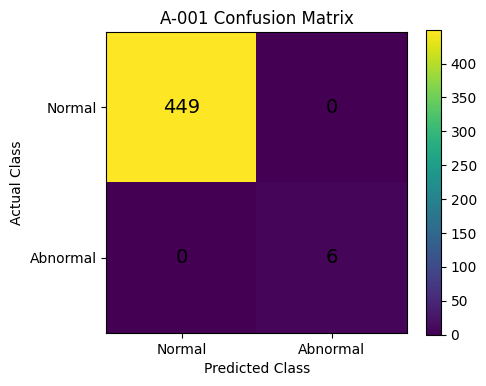

In [0]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("A-001 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Normal", "Abnormal"])
plt.yticks([0, 1], ["Normal", "Abnormal"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.colorbar()
plt.tight_layout()
plt.show()

## Important discussion: why can accuracy be misleading?

Our A-001 dataset contains many more Normal readings than Abnormal readings.

A model that predicts **Normal almost every time** could still look very accurate.

That is why rare-event problems should also use:

- Recall
- Precision
- Confusion matrix
- Balanced metrics

# PART 12 — Inspect the Rule the Model Learned

Because the tree has only one split, we can see the threshold directly.

In [0]:
threshold = model.tree_.threshold[0]

print(f"Learned vibration threshold: approximately {threshold:.3f} mm/s")
print()
print(f"If vibration <= {threshold:.3f} mm/s → NORMAL")
print(f"If vibration >  {threshold:.3f} mm/s → ABNORMAL")

Learned vibration threshold: approximately 5.007 mm/s

If vibration <= 5.007 mm/s → NORMAL
If vibration >  5.007 mm/s → ABNORMAL


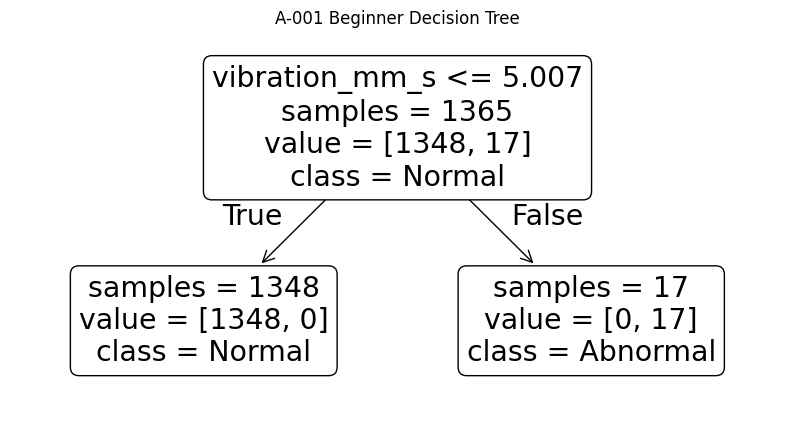

In [0]:
plt.figure(figsize=(10, 5))
plot_tree(
    model,
    feature_names=["vibration_mm_s"],
    class_names=["Normal", "Abnormal"],
    filled=False,
    rounded=True,
    impurity=False,
)
plt.title("A-001 Beginner Decision Tree")
plt.show()

# PART 13 — Turn the Model into a Tiny A-001 Classifier

This is a simple way to make the notebook feel like an application.

Give it a vibration value and it returns:

- the prediction
- the meaning
- the learned threshold

In [0]:
def classify_a001(vibration_mm_s):
    new_data = pd.DataFrame({
        "vibration_mm_s": [vibration_mm_s]
    })

    prediction = int(model.predict(new_data)[0])
    meaning = "NORMAL" if prediction == 0 else "ABNORMAL"

    return {
        "asset": "A-001",
        "vibration_mm_s": vibration_mm_s,
        "prediction": prediction,
        "meaning": meaning,
        "learned_threshold_mm_s": round(float(threshold), 3),
    }

classify_a001(4.8)

{'asset': 'A-001',
 'vibration_mm_s': 4.8,
 'prediction': 0,
 'meaning': 'NORMAL',
 'learned_threshold_mm_s': 5.007}

## Try several new readings

In [0]:
new_readings = pd.DataFrame({
    "vibration_mm_s": [1.2, 3.0, 4.8, 5.0, 5.2, 5.5]
})

new_readings["prediction"] = model.predict(new_readings)
new_readings["meaning"] = new_readings["prediction"].map({
    0: "NORMAL",
    1: "ABNORMAL",
})

display(new_readings)

vibration_mm_s,prediction,meaning
1.2,0,NORMAL
3.0,0,NORMAL
4.8,0,NORMAL
5.0,0,NORMAL
5.2,1,ABNORMAL
5.5,1,ABNORMAL


# PART 14 — Student Exploration Lab

Now let participants **play with the data**.

The goal is not to copy code.  
The goal is to ask questions and see what happens.

## Exercise A — Pick another variable for univariate analysis

Try one of:

- `pressure_bar`
- `flow_rate_m3_h`
- `ambient_temperature_c`

Questions:

1. What is its average?
2. What is its min/max?
3. What does its histogram look like?
4. Does it contain unusual values?

count    1820.000000
mean        8.588885
std         0.242700
min         7.900000
25%         8.460000
50%         8.610000
75%         8.720000
max         9.300000
Name: pressure_bar, dtype: float64


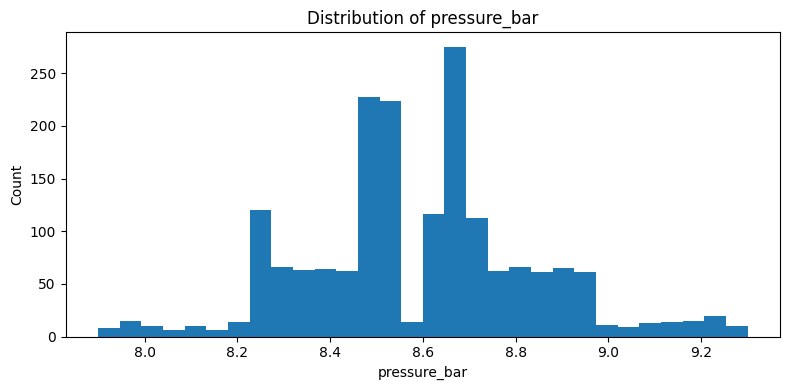

In [0]:
# TRY IT YOURSELF
column_to_explore = "pressure_bar"

print(df[column_to_explore].describe())

plt.figure(figsize=(8, 4))
plt.hist(df[column_to_explore], bins=30)
plt.xlabel(column_to_explore)
plt.ylabel("Count")
plt.title(f"Distribution of {column_to_explore}")
plt.tight_layout()
plt.show()

## Exercise B — Try another bivariate relationship

Change `y_column` and see what happens.

In [0]:
# TRY IT YOURSELF
x_column = "vibration_mm_s"
y_column = "flow_rate_m3_h"

plt.figure(figsize=(8, 5))
plt.scatter(df[x_column], df[y_column], alpha=0.6)
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.title(f"{x_column} vs {y_column}")
plt.tight_layout()
plt.show()

print("Correlation:", round(df[x_column].corr(df[y_column]), 3))

## Exercise C — Train the same simple tree using a DIFFERENT single feature

This is a great experiment.

Try:

- temperature
- current
- pressure
- flow

Then compare the metrics.

### Question

Does a different feature perform as well as vibration?

In [0]:
# TRY IT YOURSELF
experimental_feature = "temperature_c"

X_exp = df[[experimental_feature]]

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

experimental_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42,
)

experimental_model.fit(X_train_exp, y_train_exp)

experimental_predictions = experimental_model.predict(X_test_exp)

print("Experimental feature:", experimental_feature)
print("Accuracy:", round(accuracy_score(y_test_exp, experimental_predictions) * 100, 2), "%")
print("Recall:", round(recall_score(y_test_exp, experimental_predictions, zero_division=0) * 100, 2), "%")
print("F1:", round(f1_score(y_test_exp, experimental_predictions, zero_division=0) * 100, 2), "%")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_exp, experimental_predictions))

# OPTIONAL — Multi-feature experiment

This is **not required for the beginner project**.

Only try this after the one-feature model is understood.

Here we allow the Decision Tree to look at several sensor variables.

In [0]:



multi_features = [
    "vibration_mm_s",
    "temperature_c"
    #"pressure_bar",
   # "flow_rate_m3_h",
    #"electrical_current_a",
   # "ambient_temperature_c",
]

X_multi = df[multi_features]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

multi_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42,
)

multi_model.fit(X_train_multi, y_train_multi)

multi_predictions = multi_model.predict(X_test_multi)

print("OPTIONAL multi-feature model")
print("Accuracy:", round(accuracy_score(y_test_multi, multi_predictions) * 100, 2), "%")
print("Recall:", round(recall_score(y_test_multi, multi_predictions, zero_division=0) * 100, 2), "%")
print("F1:", round(f1_score(y_test_multi, multi_predictions, zero_division=0) * 100, 2), "%")

OPTIONAL multi-feature model
Accuracy: 100.0 %
Recall: 100.0 %
F1: 100.0 %


Full multi-feature model (max_depth=2)
Features: ['vibration_mm_s', 'temperature_c', 'pressure_bar', 'flow_rate_m3_h', 'electrical_current_a', 'ambient_temperature_c']
Accuracy: 100.0 %
Recall: 100.0 %
Precision: 100.0 %
F1: 100.0 %

Confusion Matrix:
[[449   0]
 [  0   6]]



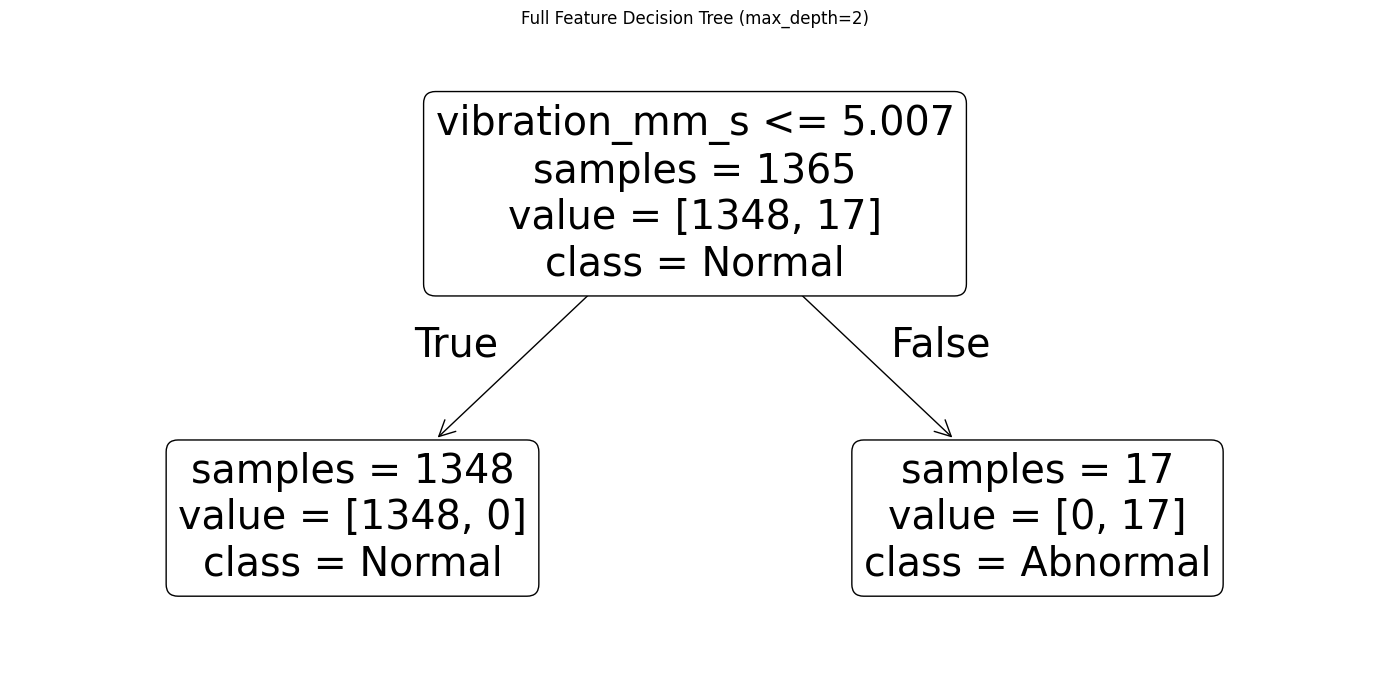

feature,importance
vibration_mm_s,1.0
temperature_c,0.0
pressure_bar,0.0
flow_rate_m3_h,0.0
electrical_current_a,0.0
ambient_temperature_c,0.0


In [0]:
full_features = [
    "vibration_mm_s",
    "temperature_c",
    "pressure_bar",
    "flow_rate_m3_h",
    "electrical_current_a",
    "ambient_temperature_c",
]

X_full = df[full_features]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

full_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42,
)

full_model.fit(X_train_full, y_train_full)

full_predictions = full_model.predict(X_test_full)

print("Full multi-feature model (max_depth=2)")
print("Features:", full_features)
print("Accuracy:", round(accuracy_score(y_test_full, full_predictions) * 100, 2), "%")
print("Recall:", round(recall_score(y_test_full, full_predictions, zero_division=0) * 100, 2), "%")
print("Precision:", round(precision_score(y_test_full, full_predictions, zero_division=0) * 100, 2), "%")
print("F1:", round(f1_score(y_test_full, full_predictions, zero_division=0) * 100, 2), "%")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_full, full_predictions))
print()

plt.figure(figsize=(14, 7))
plot_tree(
    full_model,
    feature_names=full_features,
    class_names=["Normal", "Abnormal"],
    filled=False,
    rounded=True,
    impurity=False,
)
plt.title("Full Feature Decision Tree (max_depth=2)")
plt.tight_layout()
plt.show()

feature_importance_full = pd.DataFrame({
    "feature": full_features,
    "importance": full_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance_full)

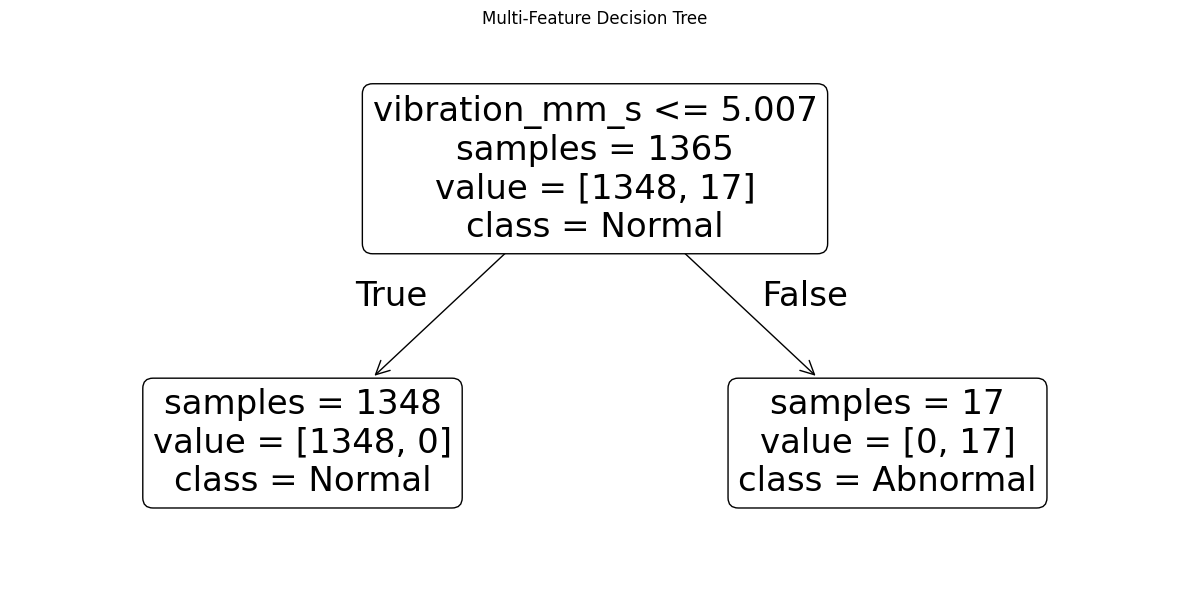

In [0]:
plt.figure(figsize=(12, 6))
plot_tree(
    multi_model,
    feature_names=multi_features,
    class_names=["Normal", "Abnormal"],
    filled=False,
    rounded=True,
    impurity=False,
)
plt.title("Multi-Feature Decision Tree")
plt.tight_layout()
plt.show()

In [0]:
feature_importance = pd.DataFrame({
    "feature": multi_features,
    "importance": multi_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

# FINAL TAKEAWAYS

You have now completed much more than “train a model”.

You practiced the real workflow:

**Database → Data → Quality Checks → EDA → Features → Target → Train/Test → Model → Prediction → Evaluation → Interpretation**

### Core beginner project

**A-001 vibration → Decision Tree → Normal / Abnormal**

### What should happen after an Abnormal result?

Not an automatic maintenance action.

Instead:

**Prediction → inspect evidence → review work orders / reports / approved procedures → qualified human decision**

That becomes our bridge into **Generative AI + RAG**.

For 1 min reading with 525K rows of data

Shape: (525600, 12)
Columns: ['reading_timestamp', 'asset_id', 'temperature_c', 'vibration_mm_s', 'pressure_bar', 'flow_rate_m3_h', 'electrical_current_a', 'ambient_temperature_c', 'sensor_quality', 'anomaly_flag', 'operating_state', 'data_origin']



reading_timestamp,asset_id,temperature_c,vibration_mm_s,pressure_bar,flow_rate_m3_h,electrical_current_a,ambient_temperature_c,sensor_quality,anomaly_flag,operating_state,data_origin
2026-07-11T03:00:00,A-001,53.109,1.4273,8.897,94.717,38.989,35.806,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
2026-07-11T03:01:00,A-001,53.115,1.4332,8.896,94.708,38.979,35.795,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
2026-07-11T03:02:00,A-001,53.121,1.4391,8.896,94.703,38.966,35.784,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
2026-07-11T03:03:00,A-001,53.129,1.4447,8.896,94.702,38.95,35.774,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC
2026-07-11T03:04:00,A-001,53.137,1.4496,8.896,94.708,38.931,35.764,GOOD,0,RUNNING,TRAINING_SIMULATED_DETERMINISTIC


Feature (X): vibration_mm_s
Target  (Y): anomaly_flag

Class distribution:
anomaly_flag
0    516791
1      8809
Name: count, dtype: int64

─ Univariate analysis: vibration_mm_s ─
count    525600.000000
mean          1.449872
std           0.806634
min           0.958600
25%           1.131000
50%           1.221500
75%           1.330500
max           5.754000
Name: vibration_mm_s, dtype: float64



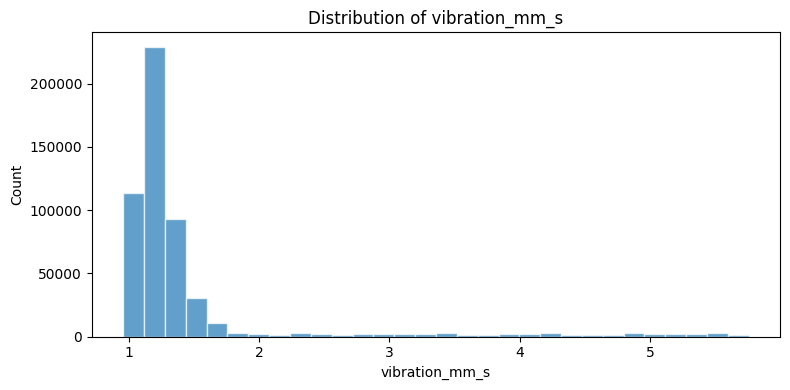

─ Bivariate analysis: vibration_mm_s vs anomaly_flag ─


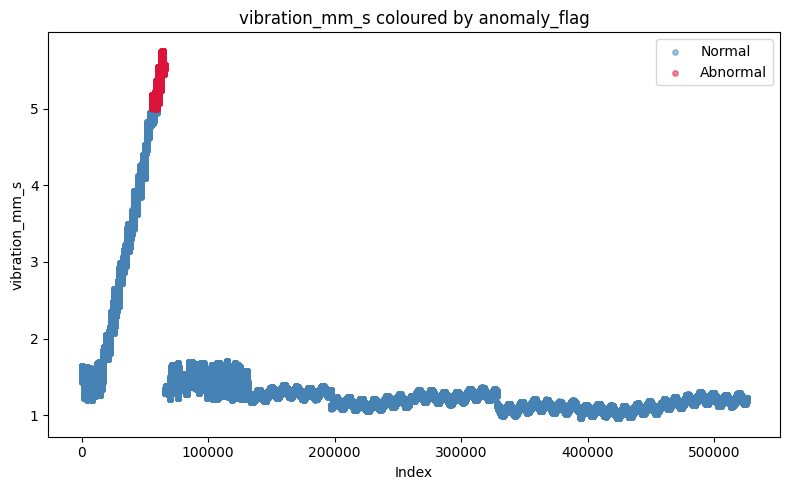

─ Correlation ─
Pearson correlation (vibration_mm_s vs anomaly_flag): 0.6310



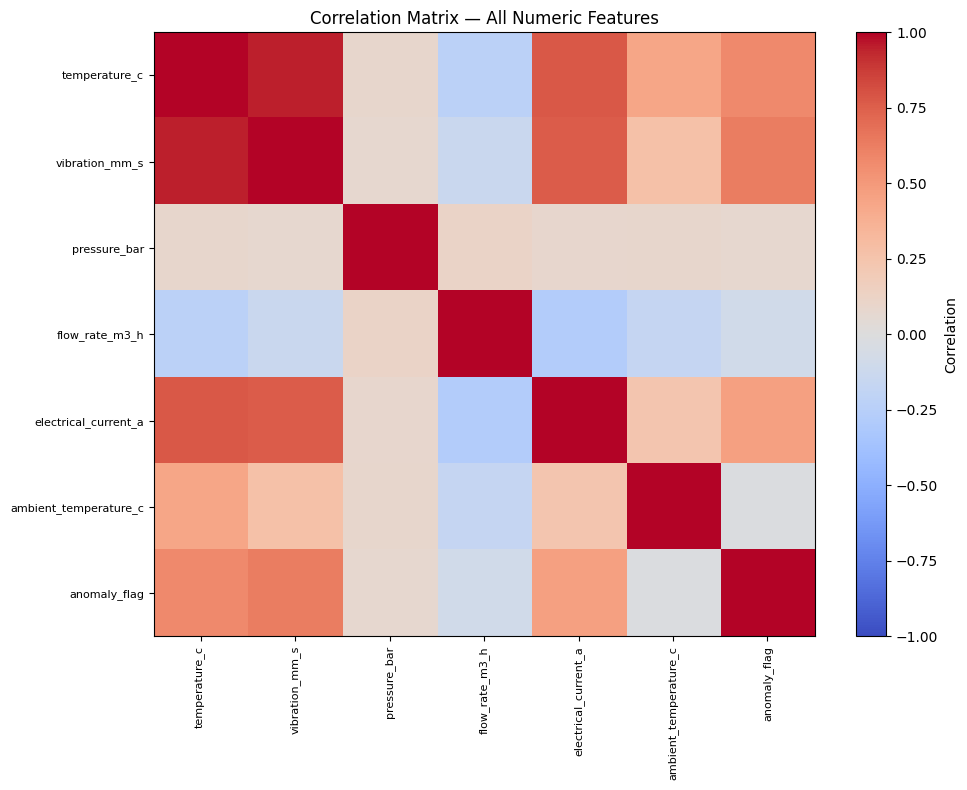

─ Train / Test Split (75-25, stratified) ─
Train: 394200 rows   Test: 131400 rows
Train class balance:
anomaly_flag
0    0.9832
1    0.0168
Name: proportion, dtype: float64

─ Train Decision Tree (max_depth=1) ─
Model trained on TRAIN data. ✓

─ Evaluation on TEST data ─
Accuracy:  100.00%
Recall:    100.00%
Precision: 100.00%
F1 Score:  100.00%

Confusion Matrix:
[[129198      0]
 [     0   2202]]



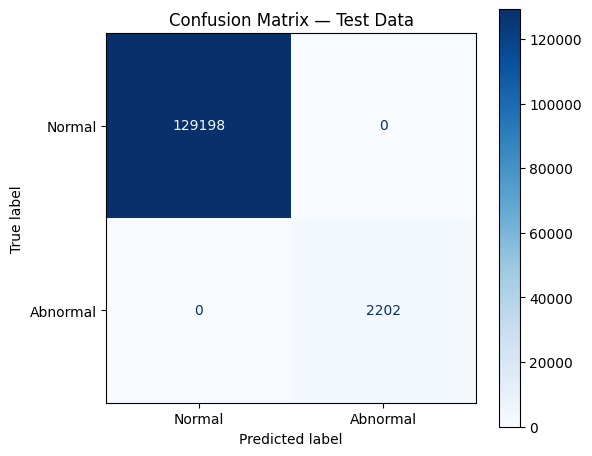

─ Learned Threshold ─
Learned vibration_mm_s threshold: approximately 5.000
If vibration_mm_s <= 5.000 → NORMAL
If vibration_mm_s >  5.000 → ABNORMAL

─ Decision Tree Plot ─


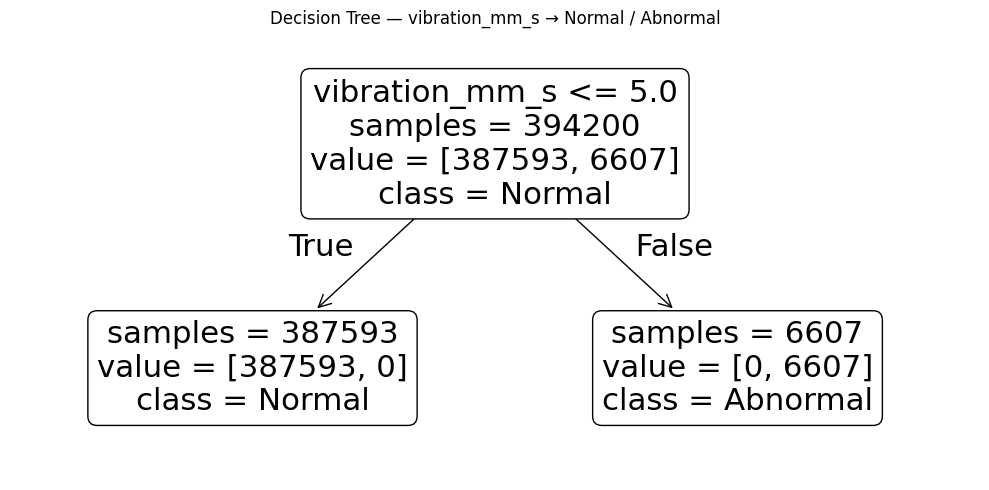

✅ Pipeline complete — all 9 steps finished.


In [0]:
# ============================================================
# COMPLETE 9-STEP DECISION TREE PIPELINE
# Table: v5_nuclear_enterprise_360.v5_nuclear_enterprise_360.sensor_readings_a001_1min
# Feature (X): vibration   Target (Y): abnormality_flag
# 75-25 stratified split — train on train, test on test
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# ── STEP 1: LOAD DATA ──
df = spark.sql(
    "SELECT * FROM v5_nuclear_enterprise_360.v5_nuclear_enterprise_360.sensor_readings_a001_1min"
).toPandas()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
display(df.head())

# ── Auto-detect feature & target column names ──
vibration_candidates = [c for c in df.columns if "vibration" in c.lower()]
vibration_col = vibration_candidates[0] if vibration_candidates else "vibration_mm_s"

flag_candidates = [c for c in df.columns if "abnormal" in c.lower() or "anomaly" in c.lower()]
flag_col = flag_candidates[0] if flag_candidates else "anomaly_flag"

print(f"Feature (X): {vibration_col}")
print(f"Target  (Y): {flag_col}")
print()

# ── Prepare X and y ──
X = df[[vibration_col]].copy()
y = df[flag_col].copy()

# If the flag is boolean or string, map to 0/1
if y.dtype == bool:
    y = y.astype(int)
elif y.dtype == object:
    unique_vals = y.unique()
    print("Target unique values:", unique_vals)
    # Map normal/abnormal strings to 0/1
    mapping = {}
    for val in unique_vals:
        lv = str(val).lower()
        if "abnormal" in lv or lv in ("1", "true", "yes"):
            mapping[val] = 1
        else:
            mapping[val] = 0
    y = y.map(mapping)
    print("Target mapping:", mapping)
    print()

print("Class distribution:")
print(y.value_counts())
print()

# ── STEP 2: UNIVARIATE ANALYSIS ──
print(f"─ Univariate analysis: {vibration_col} ─")
print(df[vibration_col].describe())
print()

plt.figure(figsize=(8, 4))
plt.hist(df[vibration_col], bins=30, edgecolor="white", alpha=0.7)
plt.xlabel(vibration_col)
plt.ylabel("Count")
plt.title(f"Distribution of {vibration_col}")
plt.tight_layout()
plt.show()

# ── STEP 3: BIVARIATE ANALYSIS (vibration vs target) ──
print(f"─ Bivariate analysis: {vibration_col} vs {flag_col} ─")

plt.figure(figsize=(8, 5))
for label_val, colour in zip([0, 1], ["steelblue", "crimson"]):
    subset = df[y == label_val]
    label_name = "Normal" if label_val == 0 else "Abnormal"
    plt.scatter(subset.index, subset[vibration_col],
                alpha=0.5, s=15, c=colour, label=label_name)
plt.xlabel("Index")
plt.ylabel(vibration_col)
plt.title(f"{vibration_col} coloured by {flag_col}")
plt.legend()
plt.tight_layout()
plt.show()

# ── STEP 4: CORRELATION ──
print("─ Correlation ─")
corr_value = df[vibration_col].corr(y)
print(f"Pearson correlation ({vibration_col} vs {flag_col}): {corr_value:.4f}")
print()

# Correlation among all numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = numeric_df.corr()
    im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, label="Correlation")
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=8)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=8)
    plt.title("Correlation Matrix — All Numeric Features")
    plt.tight_layout()
    plt.show()

# ── STEP 5: TRAIN / TEST SPLIT (75-25, stratified) ──
print("─ Train / Test Split (75-25, stratified) ─")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y,
)
print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(4)}")
print()

# ── STEP 6: TRAIN DECISION TREE (max_depth=1, single split) ──
print("─ Train Decision Tree (max_depth=1) ─")
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)
print("Model trained on TRAIN data. ✓")
print()

# ── STEP 7: EVALUATE ON TEST DATA ──
print("─ Evaluation on TEST data ─")
y_pred = model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred, zero_division=0) * 100:.2f}%")
print()

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal"]).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix — Test Data")
plt.tight_layout()
plt.show()

# ── STEP 8: THRESHOLD VALUE ──
print("─ Learned Threshold ─")
threshold = model.tree_.threshold[0]
print(f"Learned {vibration_col} threshold: approximately {threshold:.3f}")
print(f"If {vibration_col} <= {threshold:.3f} → NORMAL")
print(f"If {vibration_col} >  {threshold:.3f} → ABNORMAL")
print()

# ── STEP 9: DECISION TREE PLOT ──
print("─ Decision Tree Plot ─")
plt.figure(figsize=(10, 5))
plot_tree(
    model,
    feature_names=[vibration_col],
    class_names=["Normal", "Abnormal"],
    filled=False,
    rounded=True,
    impurity=False,
)
plt.title(f"Decision Tree — {vibration_col} → Normal / Abnormal")
plt.tight_layout()
plt.show()

print("✅ Pipeline complete — all 9 steps finished.")